# Cancer Subtyping + Aging Pipeline (Full Demonstration)

This notebook runs the complete computational pipeline:

1. Preprocessing of transcriptomic and clinical data  
2. Feature extraction and dimensionality reduction  
3. Tumor clustering (subtyping)  
4. Pathway enrichment (GSEA)  
5. Aging signature scoring  
6. Survival analysis  
7. Visualization and export of results  

Each step includes a short explanation to clarify the biological and computational purpose.

In [1]:
# =========================
# PIPELINE PARAMETERS
# =========================

N_CLUSTERS_RANGE = (2, 8)
TOP_GENES = 5000
USE_SURVIVAL = True
RANDOM_STATE = 42
FIGSIZE = (8, 6)

In [2]:
from pathlib import Path
import os

os.chdir("..")

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from pipelines.preprocessing_pipeline import run_preprocessing
from pipelines.feature_pipeline import run_feature_pipeline
from pipelines.clustering_pipeline import run_clustering_pipeline
from pipelines.gsea_pipeline import run_gsea_pipeline
from pipelines.survival_pipeline import run_survival_pipeline

from analysis.pathway_analysis import build_nes_matrix
from analysis.aging_analysis import compute_aging_scores

from plots.plot_gsea import plot_pathway_heatmap
from plots.plot_aging import plot_aging_scores, plot_aging_heatmap

## Step 1 — Preprocessing

We load and clean expression + clinical data, ensuring consistency between samples.

This step removes noise and prepares the dataset for downstream statistical analysis.

In [4]:
expr, clinical = run_preprocessing()

print(expr.shape, clinical.shape)


[STEP] Loading data...
[INFO] Expression shape: (20530, 1219)
[INFO] Clinical shape: (1236, 11)

[STEP] Preprocessing...
Index(['time', 'event'], dtype='object')

[STEP] Aligning datasets...
(1214, 20252) (1214, 2)


## Step 2 — Feature Engineering

We reduce dimensionality and prepare survival-compatible matrices.

This step helps extract biologically meaningful variation and removes redundancy.

In [5]:
expr_filtered, expr_survival, X_pca = run_feature_pipeline(expr, clinical)


[STEP] Feature filtering...
[INFO] Variance filtering: 20252 → 20252 genes
[INFO] Top-5000 genes selected

[STEP] Survival feature selection...
Index(['time', 'event'], dtype='object')
[DEBUG] expr_filtered shape: (1214, 5000)

[STEP] Scaling...

[STEP] PCA...


## Step 3 — Tumor Subtyping (Clustering)

We identify molecular tumor subtypes using unsupervised learning.

This step reveals hidden biological structure in the cohort.

In [6]:
X_umap, labels, best_k, model = run_clustering_pipeline(X_pca)

print("Optimal number of clusters:", best_k)


[STEP] UMAP...


C:\Users\jimad\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



[STEP] Clustering (k search 2–5)...
[CLUSTERING] Testing k=2
[CLUSTERING] Testing k=3
[CLUSTERING] Testing k=4
[CLUSTERING] Testing k=5
[INFO] Best k: 2
[INFO] Silhouette: 0.2590883429712211
[INFO] Clustering results: {'method': 'gmm', 'n_clusters': 2, 'silhouette_score': 0.2591, 'davies_bouldin_score': 1.468, 'bic': 115104.7, 'aic': 112752.83}
Optimal number of clusters: 2


In [7]:
import numpy as np

clusters = pd.DataFrame({
    "cluster": labels
}, index=expr_filtered.index)

clusters["cluster"].value_counts()

cluster
0    1019
1     195
Name: count, dtype: int64

## Step 4 — Pathway Enrichment (GSEA)

We identify biological pathways enriched in each tumor subtype.

This connects molecular data to functional biology.

In [8]:
gsea_df = run_gsea_pipeline(expr_survival, clusters)

[GSEA] cluster 0
[GSEA] cluster 1


In [9]:
nes_matrix = build_nes_matrix(gsea_df)

## Step 5 — Aging Signatures

We compute aging-related pathway scores across tumor subtypes.

This allows linking tumor biology with aging processes.

In [10]:
aging_scores = compute_aging_scores(gsea_df)

## Step 6 — Visualization

We visualize tumor structure, pathway activity, and aging-related biological signals across molecular subtypes.

These plots help interpret the biological differences between tumor groups identified by clustering.

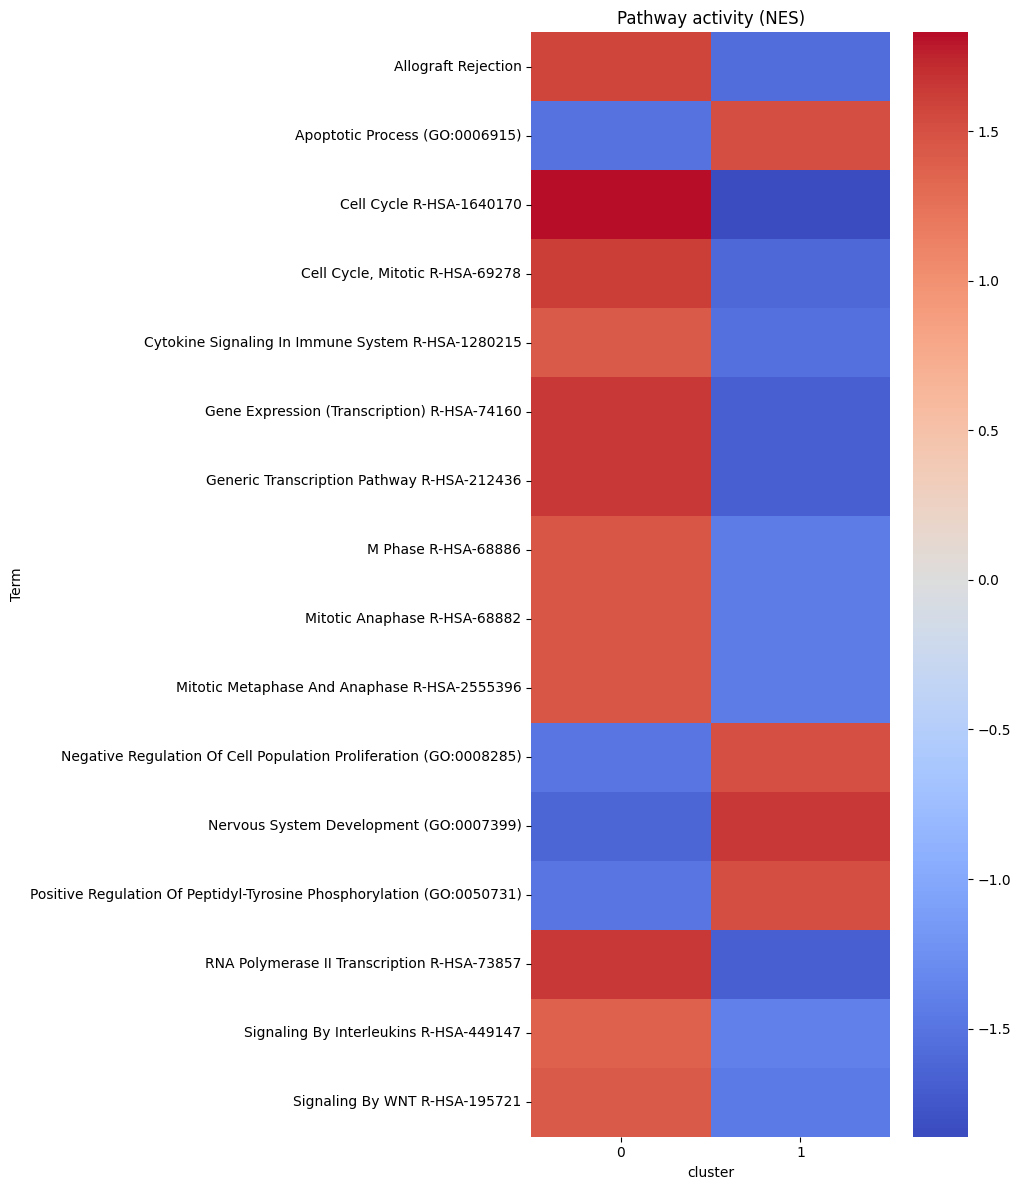

In [11]:
# =========================
# PATHWAY ENRICHMENT HEATMAP
# =========================

plot_pathway_heatmap(gsea_df)

Biological Interpretation — Pathway Heatmap

The pathway heatmap summarizes the activity of biological pathways across tumor subtypes using normalized enrichment scores (NES) from GSEA.

Key biological insights include:

Rows represent biological pathways (e.g. inflammation, metabolism, DNA repair)
Columns represent tumor subtypes identified by clustering
Positive enrichment indicates pathway activation
Negative enrichment indicates pathway suppression

This visualization helps identify:

subtype-specific oncogenic programs
immune-active vs immune-suppressed tumors
metabolic rewiring patterns
stress-response and proliferation signatures

For example:

strong enrichment of cell-cycle pathways may indicate aggressive proliferative tumors
enrichment of inflammatory or interferon pathways may reflect immune infiltration
suppression of mitochondrial pathways may suggest metabolic dysfunction

Distinct pathway patterns support the idea that tumors are biologically heterogeneous and may respond differently to therapy.

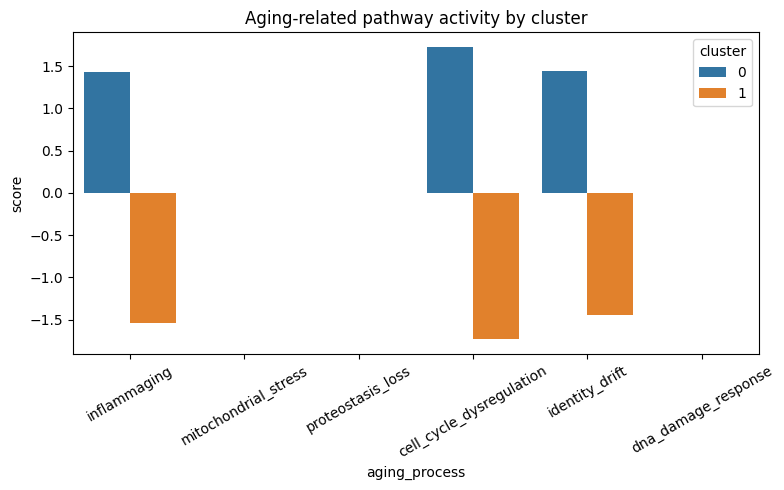

In [12]:
# =========================
# AGING SIGNATURE SCORES
# =========================

plot_aging_scores(aging_scores)

Biological Interpretation — Aging Score Plot

This plot summarizes aging-related activity across tumor subtypes.

Aging signatures typically include pathways associated with:

cellular senescence
DNA damage accumulation
chronic inflammation
mitochondrial dysfunction
oxidative stress
stemness loss

Higher aging scores may indicate tumors with stronger age-associated molecular phenotypes.

Biologically, this can suggest:

increased genomic instability
altered immune microenvironment
accelerated tissue degeneration
senescence-associated secretory phenotype (SASP) activity

Comparing aging scores across subtypes helps determine whether specific tumor groups are more strongly linked to aging biology.

This is important because aging-associated tumors may exhibit:

distinct progression dynamics
altered treatment response
different survival outcomes

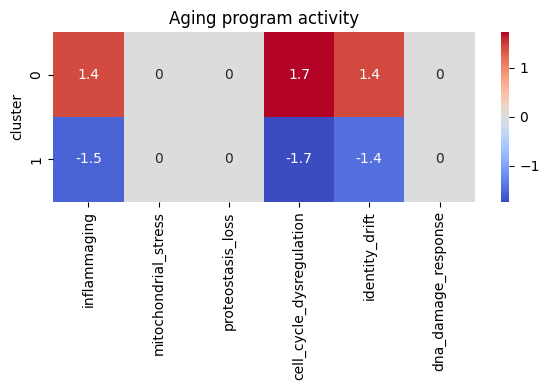

In [13]:
# =========================
# AGING HEATMAP
# =========================

plot_aging_heatmap(aging_scores)

Biological Interpretation — Aging Heatmap

The aging heatmap provides a detailed view of aging-associated pathway activity across tumor subtypes.

Unlike the summary aging score plot, this visualization highlights individual aging-related programs separately.

Examples of aging-associated signals include:

senescence pathways
telomere dysfunction
reactive oxygen species (ROS) signaling
mitochondrial stress
epigenetic aging programs
inflammatory signaling

This heatmap helps reveal:

which aging mechanisms dominate each subtype
whether aging signatures cluster together
subtype-specific aging phenotypes

For example:

a subtype enriched for senescence and inflammatory pathways may represent biologically older tumors
elevated DNA repair stress may indicate accumulated molecular damage
mitochondrial dysfunction signatures may reflect altered energy metabolism

These observations can help connect tumor heterogeneity with broader mechanisms of organismal aging.

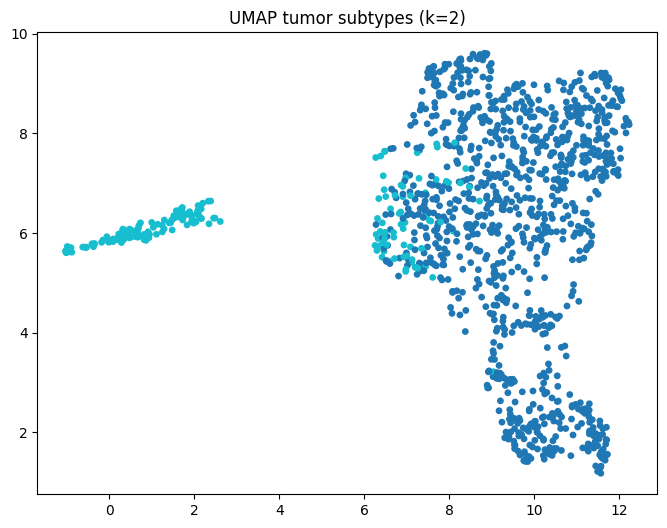

In [14]:
plt.figure(figsize=FIGSIZE)

plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=labels,
    cmap="tab10",
    s=15
)

plt.title(f"UMAP tumor subtypes (k={best_k})")
plt.show()

Biological Interpretation — UMAP Tumor Subtypes

The UMAP projection visualizes similarities between tumor samples in reduced-dimensional space.

Key interpretation:

each point represents one tumor sample
nearby points have similar transcriptomic profiles
separated groups correspond to distinct molecular subtypes

Well-separated clusters suggest strong biological differences between tumors.

These differences may arise from:

different oncogenic drivers
immune composition
metabolic state
differentiation status
aging-associated molecular programs

The UMAP plot provides an intuitive overview of tumor heterogeneity and validates the clustering strategy used for subtype discovery.

## Step 7 — Survival Analysis

We test whether tumor subtypes have different survival outcomes.


[STEP] Survival analysis...
[INFO] Log-rank test: {'test_statistic': np.float64(13.306055247476161), 'p_value': np.float64(0.0002645503588426074)}
               coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                  
cluster_1  0.579769   1.785627   0.16032        0.265547        0.893992   

           exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z  \
covariate                                                               
cluster_1             1.304144             2.444869     0.0  3.616317   

                  p   -log2(p)  
covariate                       
cluster_1  0.000299  11.708413  
   test_statistic         p  -log2(p)
0       13.306055  0.000265  11.88417


<Figure size 640x480 with 0 Axes>

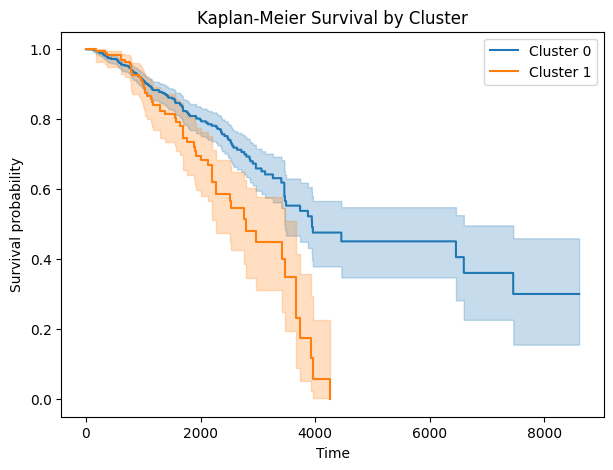

In [15]:
if USE_SURVIVAL:
    run_survival_pipeline(clinical, clusters, X_umap, labels)

In [16]:
gsea_df.to_csv("results/gsea/all_gsea_results.csv")
aging_scores.to_csv("results/aging/aging_scores.csv")

print("Pipeline completed successfully")

Pipeline completed successfully


## Biological Interpretation

- Tumor samples cluster into distinct molecular subtypes
- These subtypes show different pathway activation patterns
- Aging signatures vary across tumor groups
- Some subtypes show stronger survival associations

This suggests a link between tumor heterogeneity and aging biology.